# VedaVision — Compound Leaf Preprocessing Pipeline
**Module:** Compound Leaf Analysis  
**Goal:** Background removal → Leaflet segmentation → Feature extraction (top & bottom views)  
**Leaf types supported:**
- Trifoliate (3 leaflets, e.g. *Desmodium*)
- Pinnate sparse (e.g. *Karapincha / Murraya koenigii*)
- Pinnate dense (e.g. *Curry / Bergera koenigii*)

---
### Pipeline Overview
```
Raw Image
   ↓
Step 1 : Resize to 512×512
   ↓
Step 2 : LAB + Adaptive Threshold + ExG  → Dual-mask strategy
   ↓
Step 3 : Noise removal (connected components)
   ↓
Step 4 : Leaflet separation
         ├─ If ≥3 components → direct component labelling
         └─ If 1 blob        → skeleton-watershed with adaptive params
   ↓
Step 5 : Per-leaflet feature extraction
         ├─ Shape  : area, perimeter, aspect ratio, circularity, convexity, compactness
         ├─ Colour : LAB, HSV, ExG mean/std per channel
         ├─ Texture: GLCM contrast, energy, homogeneity, correlation; LBP histogram
         └─ Vein   : skeleton length ratio, vein density
   ↓
Step 6 : Whole-leaf features (leaflet count, arrangement, rachis)
   ↓
Step 7 : Visualisation & export (CSV)
```

## Cell 1 — Imports & Configuration

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import ndimage
from skimage.segmentation import watershed
from skimage.feature import peak_local_max, local_binary_pattern, graycomatrix, graycoprops
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops

# ── Configuration ─────────────────────────────────────────────────────────────
TARGET_SIZE   = 512        # all images resized to 512×512
MIN_COMP_FRAC = 0.001      # min component size as fraction of image (noise removal)
MIN_LEAF_FRAC = 0.008      # min leaflet size as fraction of total leaf pixels
SKEL_FLOOR    = 0.25       # suppress skeleton seeds below this fraction of dist_max
                           # (removes thin rachis seeds)
LBP_RADIUS    = 3          # LBP texture descriptor radius
LBP_POINTS    = 24         # LBP descriptor points (8 × radius)
GLCM_DIST     = [1, 3]     # GLCM distances
GLCM_ANGLES   = [0, np.pi/4, np.pi/2, 3*np.pi/4]  # GLCM angles

# Palette for visualising up to 25 leaflets
PALETTE = [
    (255,20,20),(20,220,255),(255,235,20),(255,20,255),(20,255,60),
    (255,140,20),(20,80,255),(200,200,0),(0,200,200),(200,0,200),
    (255,100,100),(100,255,100),(100,100,255),(255,180,0),(0,180,255),
    (180,0,255),(0,255,180),(180,255,0),(255,0,180),(128,255,128),
    (255,128,128),(128,128,255),(200,255,100),(100,200,255),(255,200,100)
]

def show(images, titles=None, cols=4, cmap=None, suptitle=None):
    """Utility: display a list of (image, title) tuples or plain images."""
    if titles is None:
        pairs = images
    else:
        pairs = list(zip(images, titles))
    rows = (len(pairs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    axes = np.array(axes).flatten()
    for ax, item in zip(axes, pairs):
        if isinstance(item, tuple):
            img_resized, title = item
        else:
            img_resized, title = item, ''
        if img_resized.ndim == 2:
            ax.imshow(img_resized, cmap='gray' if cmap is None else cmap)
        else:
            ax.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB) if img_resized.shape[2]==3 else img_resized)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    for ax in axes[len(pairs):]:
        ax.axis('off')
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Imports OK. TARGET_SIZE =', TARGET_SIZE)

Imports OK. TARGET_SIZE = 512


## Cell 2 — Image Loading

Using: ..\dataset\raw\kasthuri_dehi\PXL_20260429_050620941.jpg
Loaded: ..\dataset\raw\kasthuri_dehi\PXL_20260429_050620941.jpg  |  Shape: (4032, 3024, 3)  |  dtype: uint8


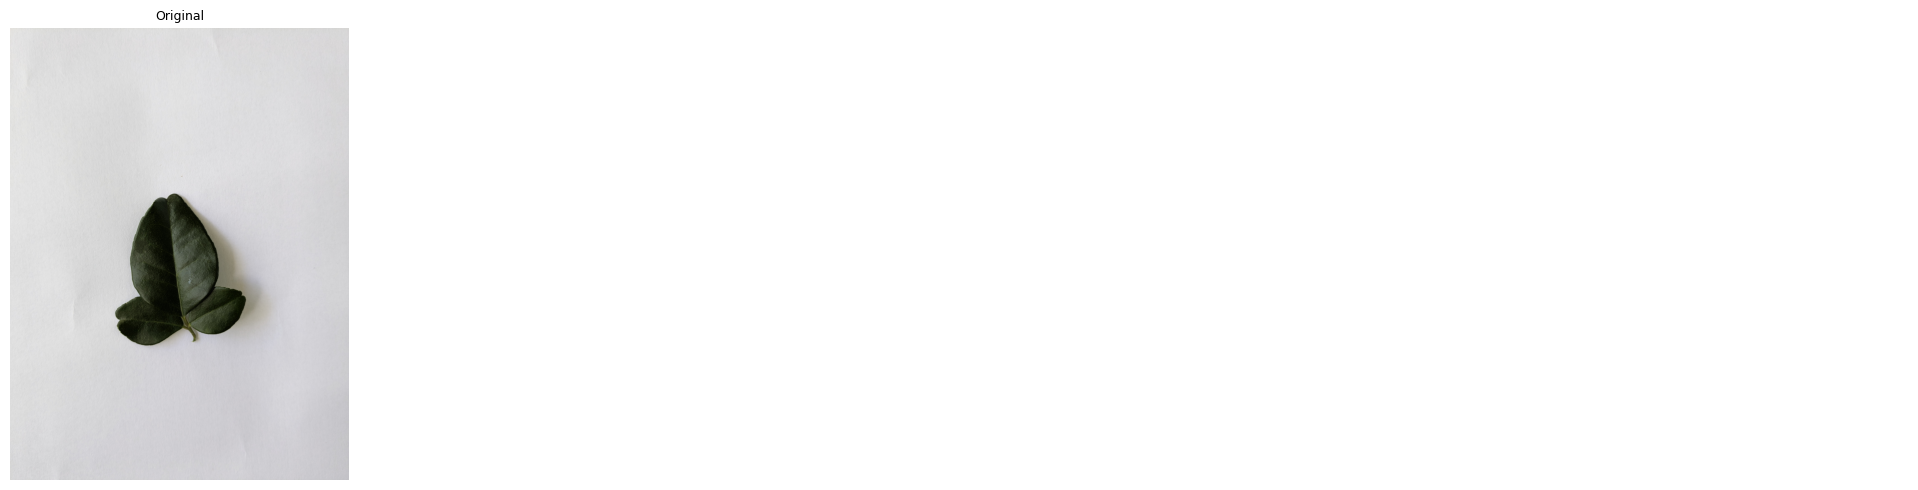

In [19]:
from pathlib import Path
import os

DATASET_RAW = '../dataset/raw/kasthuri_dehi/'
raw = Path(DATASET_RAW)
all_imgs = list(raw.rglob('*.jpg')) + list(raw.rglob('*.png'))

if not all_imgs:
    print('⚠️  No images found. Add images to dataset/raw/species_name/')
else:
    TEST_IMAGE = all_imgs[1]   # ← change index or set a specific path
    print(f'Using: {TEST_IMAGE}')
    raw_img = cv2.imread(str(TEST_IMAGE))
assert os.path.exists(TEST_IMAGE), f'Image not found: {TEST_IMAGE}'
img_orig = cv2.imread(str(TEST_IMAGE))
print(f'Loaded: {TEST_IMAGE}  |  Shape: {img_orig.shape}  |  dtype: {img_orig.dtype}')
show([(img_orig, 'Original')])



## Resize — Aspect-Ratio Preserving (Pad, then Resize)

Original  : 3024w × 4032h  AR=0.750
Scaled to : 384w × 512h  (scale=0.1270)
Padded to : 512w × 512h  pad_top=0  pad_left=64
True leaf AR preserved: 0.750 → 0.750  (should be identical)


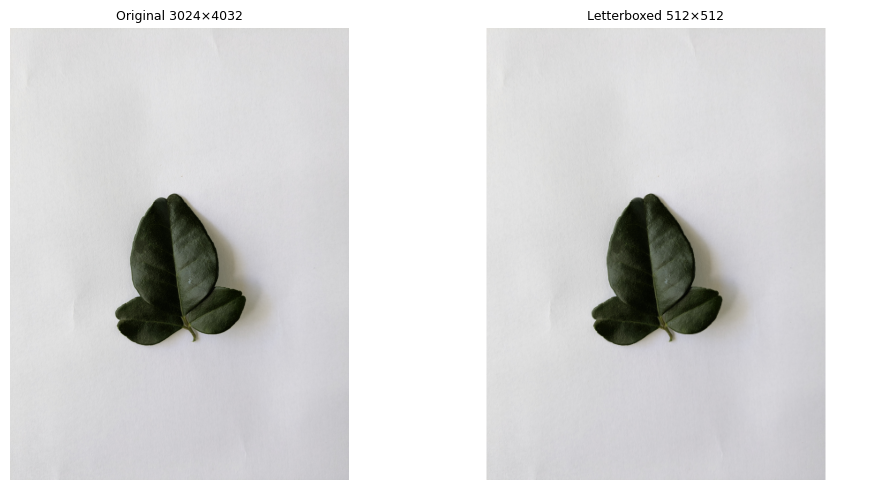

In [20]:
TARGET_LONG = 512   # longest side target in pixels

def letterbox_resize(img_orig, target_long=512, pad_colour=(255, 255, 255)):
    """
    Scale so longest side = target_long, then pad short side to make it square.
    Preserves true aspect ratio — no compaction distortion.

    pad_colour=(255,255,255): white, matching dataset background.
    This is critical: GrabCut uses border pixels to seed its background model.
    If padding were black or grey it would corrupt the background GMM.

    Returns:
        img_padded  : (target_long × target_long) uint8 BGR image
        meta        : dict with scale, pad_top, pad_left — needed to invert
                      pixel coordinates back to original image space if required.
    """
    h, w = img_orig.shape[:2]
    scale = target_long / max(h, w)   # scale factor: keeps longest side = target_long
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    # Choose interpolation based on direction
    interp = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_LINEAR
    # INTER_AREA: area averaging for downscale → prevents aliasing moiré on vein patterns
    # INTER_LINEAR: bilinear for upscale → smooth, no ringing
    img_scaled = cv2.resize(img_orig, (new_w, new_h), interpolation=interp)

    # Compute symmetric padding to reach (target_long × target_long)
    pad_h = target_long - new_h
    pad_w = target_long - new_w
    pad_top    = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left   = pad_w // 2
    pad_right  = pad_w - pad_left

    img_padded = cv2.copyMakeBorder(
        img_scaled,
        pad_top, pad_bottom, pad_left, pad_right,
        borderType=cv2.BORDER_CONSTANT,
        value=pad_colour   # white — matches dataset background
    )

    meta = dict(scale=scale, pad_top=pad_top, pad_left=pad_left,
                orig_h=h, orig_w=w, new_h=new_h, new_w=new_w)
    return img_padded, meta


img_resized, resize_meta = letterbox_resize(img_orig, TARGET_LONG)

print(f"Original  : {img_orig.shape[1]}w × {img_orig.shape[0]}h  "
      f"AR={img_orig.shape[1]/img_orig.shape[0]:.3f}")
print(f"Scaled to : {resize_meta['new_w']}w × {resize_meta['new_h']}h  "
      f"(scale={resize_meta['scale']:.4f})")
print(f"Padded to : {img_resized.shape[1]}w × {img_resized.shape[0]}h  "
      f"pad_top={resize_meta['pad_top']}  pad_left={resize_meta['pad_left']}")
print(f"True leaf AR preserved: "
      f"{resize_meta['orig_w']/resize_meta['orig_h']:.3f} → "
      f"{resize_meta['new_w']/resize_meta['new_h']:.3f}  (should be identical)")

show([(img_orig, f'Original {img_orig.shape[1]}×{img_orig.shape[0]}'),
      (img_resized, f'Letterboxed {img_resized.shape[1]}×{img_resized.shape[0]}')], cols=2)

## Cell 3 — Step 2: Dual-Mask Background Removal (LAB + ExG)

Tight mask: 1 components, 1212 px
Loose mask: 1 components, 18293 px
Selected  : loose (ExG>5)


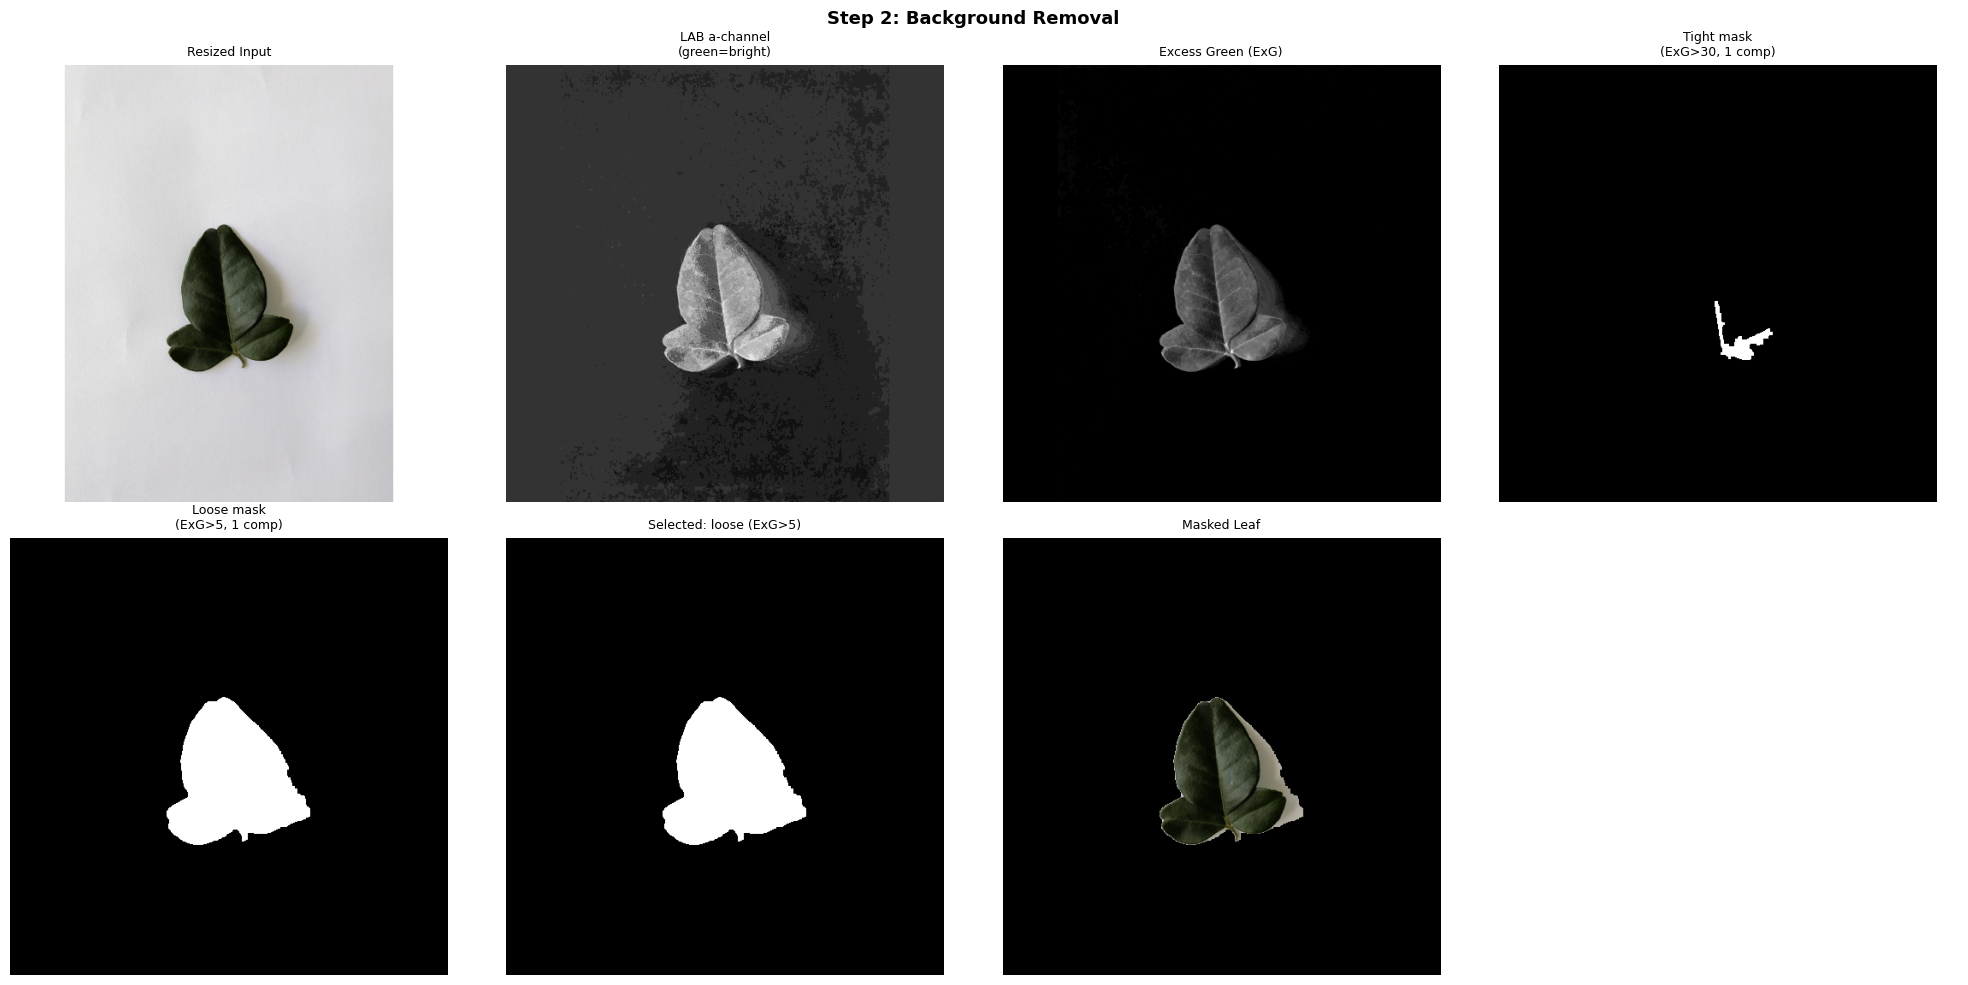

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# WHY LAB + ExG instead of GrabCut + HSV:
#   • GrabCut + large closing merges inter-leaflet gaps → wrong leaflet count
#   • LAB 'a' channel (green↔red axis) naturally separates green leaf from
#     white/grey paper background without needing a bounding rectangle
#   • Adaptive threshold handles uneven illumination & paper shadows
#   • ExG (Excess Green = 2G−R−B) acts as a saturation guard:
#     white paper: ExG ≈ 0 | dark leaf: ExG > 5 | bright leaf: ExG > 30
#   • Dual-mask strategy: tight (ExG>30) preserves leaflet gaps for sparse leaves
#                         loose (ExG>5)  captures dark leaves without gaps
# ─────────────────────────────────────────────────────────────────────────────

def _build_mask(img_bgr, exg_threshold, morph_close_iter=2):
    """Build a binary leaf mask using LAB adaptive threshold + ExG filter."""
    # LAB 'a' channel: invert so green pixels are bright
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    _, a, _ = cv2.split(lab)
    green_map = cv2.bitwise_not(a)

    # Adaptive threshold on the inverted 'a' channel
    # block_size=55 is tuned for 512px; scale if using different TARGET_SIZE
    block_size = max(11, (TARGET_SIZE // 9) | 1)  # odd, ~55 at 512px
    mask_lab = cv2.adaptiveThreshold(
        green_map, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block_size, 10
    )

    # Excess Green vegetation index
    img_f = img_bgr.astype(np.float32)
    exg = 2 * img_f[:, :, 1] - img_f[:, :, 2] - img_f[:, :, 0]
    mask_exg = (exg > exg_threshold).astype(np.uint8) * 255

    # Combine: pixel must satisfy BOTH green-channel AND vegetation tests
    combined = cv2.bitwise_and(mask_lab, mask_exg)

    # Small morphological cleanup
    k3 = np.ones((3, 3), np.uint8)
    combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN,  k3, iterations=1)
    combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, k3, iterations=morph_close_iter)
    return combined


def _remove_noise(mask, min_frac=MIN_COMP_FRAC):
    """Remove connected components smaller than min_frac of image."""
    min_area = TARGET_SIZE * TARGET_SIZE * min_frac
    n, lbl_map, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] > min_area:
            clean[lbl_map == i] = 255
    return clean


# ── Dual-mask strategy ────────────────────────────────────────────────────────
mask_tight = _remove_noise(_build_mask(img_resized, exg_threshold=30))   # preserves gaps
mask_loose = _remove_noise(_build_mask(img_resized, exg_threshold=5))    # captures dark leaves

n_tight = cv2.connectedComponentsWithStats(mask_tight)[0] - 1
n_loose = cv2.connectedComponentsWithStats(mask_loose)[0] - 1
tight_px = (mask_tight > 0).sum()
loose_px = (mask_loose > 0).sum()

# Choose tight mask if it gives ≥3 well-separated regions (good inter-leaflet gaps)
# Otherwise fall back to loose mask (for dark/dense leaves where ExG>30 cuts too much)
use_tight = (n_tight >= 3) and (tight_px > loose_px * 0.3)
mask_final = mask_tight if use_tight else mask_loose
mask_choice = 'tight (ExG>30)' if use_tight else 'loose (ExG>5)'

print(f'Tight mask: {n_tight} components, {tight_px} px')
print(f'Loose mask: {n_loose} components, {loose_px} px')
print(f'Selected  : {mask_choice}')

img_masked = cv2.bitwise_and(img_resized, img_resized, mask=mask_final)

# Compute ExG image for visualisation
img_f32 = img_resized.astype(np.float32)
exg_vis = 2*img_f32[:,:,1] - img_f32[:,:,2] - img_f32[:,:,0]
exg_vis = np.clip(exg_vis, 0, 255).astype(np.uint8)

# LAB 'a' channel visualisation
lab_vis = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB)
a_ch = cv2.bitwise_not(cv2.split(lab_vis)[1])  # inverted 'a'

show([
    (img_resized,          'Resized Input'),
    (a_ch,         'LAB a-channel\n(green=bright)'),
    (exg_vis,      'Excess Green (ExG)'),
    (mask_tight,   f'Tight mask\n(ExG>30, {n_tight} comp)'),
    (mask_loose,   f'Loose mask\n(ExG>5, {n_loose} comp)'),
    (mask_final,   f'Selected: {mask_choice}'),
    (img_masked,   'Masked Leaf'),
], cols=4, suptitle='Step 2: Background Removal')

## Cell 4 — Step 3: Sharpening & Enhancement (for feature extraction)

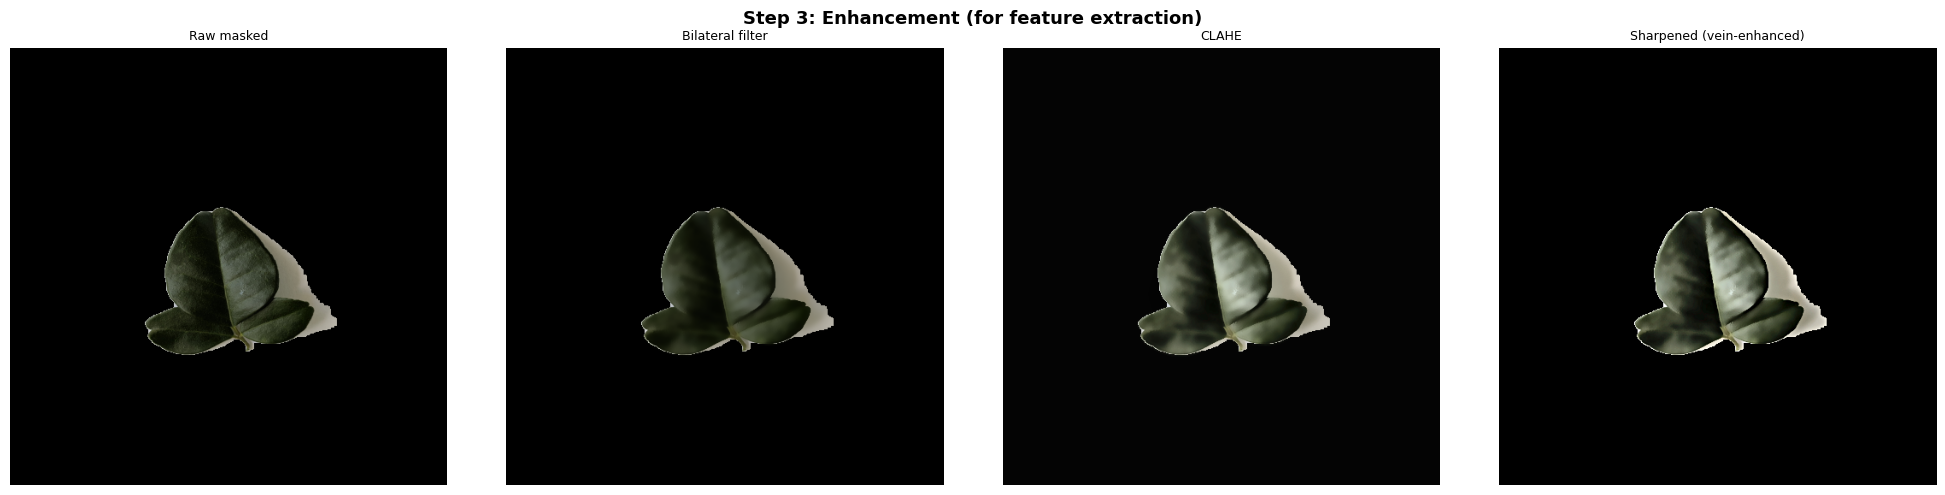

In [16]:
# ── Enhancement pipeline (applied ONLY to the masked leaf region) ─────────────
# Used downstream for texture & vein feature extraction.
# NOT used for segmentation (segmentation uses raw masked image).

# Bilateral filter: smooths within-leaflet noise while preserving vein edges
img_bilateral = cv2.bilateralFilter(img_masked, d=9, sigmaColor=75, sigmaSpace=75)

# CLAHE on L channel: boosts local contrast for vein visibility
lab_enh = cv2.cvtColor(img_bilateral, cv2.COLOR_BGR2LAB)
l, a_e, b_e = cv2.split(lab_enh)
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
l_clahe = clahe.apply(l)
img_clahe = cv2.merge([l_clahe, a_e, b_e])
img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_LAB2BGR)

# Unsharp mask: sharpens vein structure
blur = cv2.GaussianBlur(img_clahe, (0, 0), sigmaX=3)
img_sharp = cv2.addWeighted(img_clahe, 1.5, blur, -0.5, 0)
img_sharp = cv2.bitwise_and(img_sharp, img_sharp, mask=mask_final)  # re-apply mask

show([
    (img_masked,   'Raw masked'),
    (img_bilateral,'Bilateral filter'),
    (img_clahe,    'CLAHE'),
    (img_sharp,    'Sharpened (vein-enhanced)'),
], cols=4, suptitle='Step 3: Enhancement (for feature extraction)')

## Cell 5 — Step 4: Leaflet Segmentation (Adaptive Strategy)

Segmentation method : watershed (fill=0.63, min_d=15px)
Leaflets found      : 1


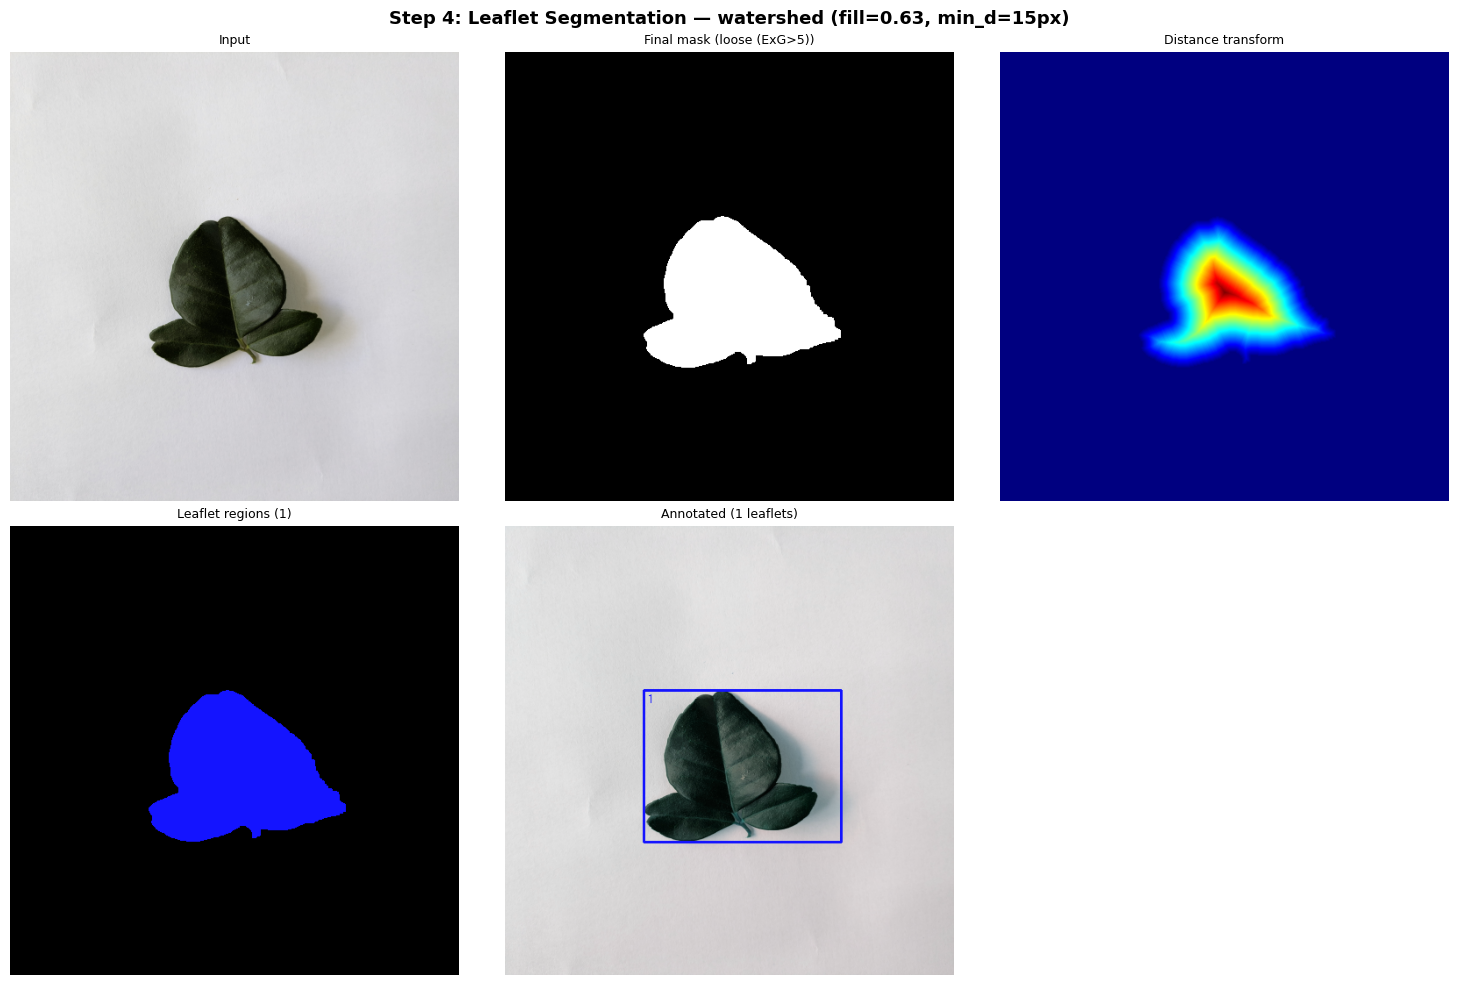

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SEGMENTATION STRATEGY:
#
# PATH A — Component-based (trifoliate / well-separated pinnate)
#   Triggered when: mask already has ≥3 significant connected components
#   Why: the inter-leaflet white-paper gaps are preserved by LAB+ExG (no over-closing)
#   How: each component = one leaflet; small per-component closing fills holes
#
# PATH B — Skeleton-Watershed (dense pinnate like curry leaf)
#   Triggered when: mask is one merged blob
#   Why: dense leaflets touch at the rachis → no natural separation in the mask
#   How:
#     1. Distance transform (thicker=brighter)
#     2. Skeletonize → multiply by distance → skel_weighted
#     3. Filter: zero out skel points where dist < 0.25×dist_max
#        (removes rachis spine seeds — rachis is thin → low dist value)
#     4. peak_local_max with adaptive min_distance:
#        min_d = dist_max × (0.75 − fill_ratio × 0.85)
#        Dense leaf (fill≈0.57) → smaller min_d → more peaks between leaflets
#        Sparse leaf (fill≈0.35) → larger min_d → fewer, cleaner peaks
#     5. Watershed on -dist with those seeds
# ─────────────────────────────────────────────────────────────────────────────

def segment_leaflets(mask, img_bgr, min_area_frac=MIN_LEAF_FRAC):
    """
    Segment leaflets from binary mask.
    Returns: list of dicts {'mask', 'bbox':(x,y,w,h), 'cy', 'area'},
             sorted top→bottom by centre-y.
    """
    n_comp, lbl_c, stats_c, _ = cv2.connectedComponentsWithStats(mask)
    sig = [i for i in range(1, n_comp)
           if stats_c[i, cv2.CC_STAT_AREA] >= TARGET_SIZE * TARGET_SIZE * min_area_frac]

    # ── PATH A: already separated ─────────────────────────────────────────────
    if len(sig) >= 3:
        leaflets = []
        ck = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        for i in sig:
            comp = (lbl_c == i).astype(np.uint8) * 255
            comp = cv2.morphologyEx(comp, cv2.MORPH_CLOSE, ck, iterations=1)
            cnts, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if cnts:
                c = max(cnts, key=cv2.contourArea)
                x, y, w, h = cv2.boundingRect(c)
                leaflets.append({
                    'mask': comp, 'bbox': (x, y, w, h),
                    'cy': y + h // 2,
                    'area': stats_c[i, cv2.CC_STAT_AREA]
                })
        leaflets.sort(key=lambda d: d['cy'])
        return leaflets, 'component-based'

    # ── PATH B: skeleton-watershed ────────────────────────────────────────────
    binary = (mask > 0).astype(np.uint8)
    dist   = cv2.distanceTransform(binary, cv2.DIST_L2, cv2.DIST_MASK_5)
    skel   = skeletonize(binary > 0)
    d_max  = dist.max()
    if d_max == 0:
        return [], 'empty'

    # Fill ratio: mask pixels / bounding-box area → leaf density
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        bx, by, bw, bh = cv2.boundingRect(max(cnts, key=cv2.contourArea))
        fill_ratio = (mask > 0).sum() / (bw * bh)
    else:
        fill_ratio = 0.5

    # Suppress rachis seeds: zero out skeleton points on thin structures
    skel_weighted = skel.astype(float) * dist
    skel_weighted[dist < d_max * SKEL_FLOOR] = 0

    # Adaptive min_distance based on leaf density
    min_d = int(np.clip(d_max * (0.75 - fill_ratio * 0.85), 5, 25))

    coords = peak_local_max(
        skel_weighted,
        min_distance=min_d,
        threshold_rel=0.10,
        labels=binary
    )
    if len(coords) == 0:
        return [], 'no_peaks'

    markers_m = np.zeros(dist.shape, dtype=bool)
    markers_m[tuple(coords.T)] = True
    markers, _ = ndimage.label(markers_m)
    labels_ws  = watershed(-dist, markers, mask=binary)

    leaflets = []
    total_px = binary.sum()
    for idx in np.unique(labels_ws):
        if idx == 0:
            continue
        region = (labels_ws == idx).astype(np.uint8) * 255
        if (region > 0).sum() < total_px * min_area_frac:
            continue
        cnts2, _ = cv2.findContours(region, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if cnts2:
            c = max(cnts2, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(c)
            leaflets.append({
                'mask': region, 'bbox': (x, y, w, h),
                'cy': y + h // 2,
                'area': int((region > 0).sum())
            })
    leaflets.sort(key=lambda d: d['cy'])
    return leaflets, f'watershed (fill={fill_ratio:.2f}, min_d={min_d}px)'


# ── Run segmentation ──────────────────────────────────────────────────────────
leaflets, seg_method = segment_leaflets(mask_final, img_resized)
n_leaflets = len(leaflets)

print(f'Segmentation method : {seg_method}')
print(f'Leaflets found      : {n_leaflets}')

# ── Visualise leaflet regions ─────────────────────────────────────────────────
# Coloured label map
lbl_vis = np.zeros((TARGET_SIZE, TARGET_SIZE, 3), dtype=np.uint8)
for i, lf in enumerate(leaflets):
    lbl_vis[lf['mask'] > 0] = PALETTE[i % len(PALETTE)]

# Annotated image with bounding boxes
ann = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB).copy()
for i, lf in enumerate(leaflets):
    x, y, w, h = lf['bbox']
    col = PALETTE[i % len(PALETTE)]
    cv2.rectangle(ann, (x, y), (x+w, y+h), col, 2)
    cv2.putText(ann, str(i+1), (x+3, y+14),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, col, 1)

# Distance transform + skeleton visualisation (for watershed path)
binary_ws = (mask_final > 0).astype(np.uint8)
dist_ws    = cv2.distanceTransform(binary_ws, cv2.DIST_L2, cv2.DIST_MASK_5)
cv2.normalize(dist_ws, dist_ws, 0, 255, cv2.NORM_MINMAX)
dist_colour = cv2.applyColorMap(dist_ws.astype(np.uint8), cv2.COLORMAP_JET)

show([
    (img_resized,           'Input'),
    (mask_final,    f'Final mask ({mask_choice})'),
    (dist_colour,   'Distance transform'),
    (lbl_vis,       f'Leaflet regions ({n_leaflets})'),
    (ann,           f'Annotated ({n_leaflets} leaflets)'),
], cols=3, suptitle=f'Step 4: Leaflet Segmentation — {seg_method}')

## Cell 6 — Step 5a: Shape Feature Extraction (per leaflet)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SHAPE FEATURES (per leaflet)
# Why shape? Leaflet shape is a primary morphological discriminator for species.
#   - Area            : size of the leaflet
#   - Perimeter       : boundary length
#   - Aspect Ratio    : width/height → oblong vs round leaflets
#   - Circularity     : 4π×area/perimeter² → 1 for circle, <1 for elongated
#   - Convexity       : convex_hull_area/area → leaflet notching/lobing
#   - Compactness     : area/bounding_box_area → how tightly packed
#   - Hu Moments      : rotation-invariant shape descriptors (7 values)
#   - Apex angle est. : approximate tip sharpness via contour curvature
# ─────────────────────────────────────────────────────────────────────────────

def extract_shape_features(leaflet_mask):
    """
    Extract shape features from a binary leaflet mask.
    Returns: dict of feature_name → value
    """
    cnts, _ = cv2.findContours(leaflet_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts:
        return {}
    cnt = max(cnts, key=cv2.contourArea)

    area      = float(cv2.contourArea(cnt))
    perimeter = float(cv2.arcLength(cnt, closed=True))

    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio  = float(w) / h if h > 0 else 0.0
    compactness   = area / (w * h) if (w * h) > 0 else 0.0
    circularity   = (4 * np.pi * area / perimeter**2) if perimeter > 0 else 0.0

    hull          = cv2.convexHull(cnt)
    hull_area     = float(cv2.contourArea(hull))
    convexity     = area / hull_area if hull_area > 0 else 0.0
    solidity      = convexity  # same metric, common name in literature

    # Equivalent diameter (diameter of circle with same area)
    eq_diameter   = float(np.sqrt(4 * area / np.pi)) if area > 0 else 0.0

    # Hu moments (rotation, scale, reflection invariant)
    M    = cv2.moments(cnt)
    hu   = cv2.HuMoments(M).flatten()
    # Log-transform Hu moments (standard practice)
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    # Minimum enclosing ellipse
    if len(cnt) >= 5:
        (ex, ey), (ma, mi), angle = cv2.fitEllipse(cnt)
        elongation = mi / ma if ma > 0 else 0.0
    else:
        elongation, angle = 0.0, 0.0

    feats = {
        'area_px'       : area,
        'perimeter_px'  : perimeter,
        'aspect_ratio'  : aspect_ratio,
        'circularity'   : circularity,
        'convexity'     : convexity,
        'solidity'      : solidity,
        'compactness'   : compactness,
        'eq_diameter_px': eq_diameter,
        'elongation'    : elongation,
        'ellipse_angle' : angle,
        'bbox_w'        : float(w),
        'bbox_h'        : float(h),
    }
    for i, val in enumerate(hu_log):
        feats[f'hu_{i+1}'] = float(val)

    return feats


# ── Run shape extraction ──────────────────────────────────────────────────────
shape_records = []
for i, lf in enumerate(leaflets):
    feats = extract_shape_features(lf['mask'])
    feats['leaflet_id'] = i + 1
    shape_records.append(feats)

df_shape = pd.DataFrame(shape_records)
print('Shape features extracted:')
print(df_shape[['leaflet_id','area_px','aspect_ratio','circularity',
                 'convexity','compactness','elongation']].to_string(index=False))

# ── Visualise shape metrics on annotated image ────────────────────────────────
shape_vis = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB).copy()
for i, lf in enumerate(leaflets):
    x, y, w, h = lf['bbox']
    col = PALETTE[i % len(PALETTE)]
    cv2.rectangle(shape_vis, (x,y), (x+w,y+h), col, 1)
    circ  = df_shape.loc[df_shape.leaflet_id==i+1, 'circularity'].values
    label = f'#{i+1} C={circ[0]:.2f}' if len(circ) else f'#{i+1}'
    cv2.putText(shape_vis, label, (x, y-3),
                cv2.FONT_HERSHEY_SIMPLEX, 0.3, col, 1)

show([
    (img_resized, 'Input'),
    (shape_vis, 'Circularity per leaflet'),
], cols=2, suptitle='Step 5a: Shape Features')

## Cell 7 — Step 5b: Colour Feature Extraction (per leaflet)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# COLOUR FEATURES (per leaflet)
# Why colour matters even for 'all-green' leaves:
#   - Hue shifts between healthy deep-green vs yellowing/diseased leaves
#   - Saturation drops with chlorosis (nutrient deficiency)
#   - LAB L* (lightness) captures top-view vs bottom-view differences
#   - LAB b* captures yellow-blue axis (relevant for leaf age/health)
#   - ExG mean quantifies overall greenness intensity
#   - Healthy vs diseased classification critically depends on subtle colour shifts
# Feature set: mean + std for each channel in BGR, HSV, LAB
# ─────────────────────────────────────────────────────────────────────────────

def extract_colour_features(img_bgr, leaflet_mask, img_sharp_bgr):
    """
    Extract colour features from the masked region of the leaf.
    Uses both raw and sharpened image to compute robust statistics.
    """
    # Convert colour spaces
    img_hsv = cv2.cvtColor(img_bgr,  cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr,  cv2.COLOR_BGR2LAB)

    # Excess Green
    img_f = img_bgr.astype(np.float32)
    exg   = (2*img_f[:,:,1] - img_f[:,:,2] - img_f[:,:,0])

    px_mask = leaflet_mask > 0  # boolean mask
    feats   = {}

    def _stats(pixels, prefix):
        """Compute mean and std for an array of pixel values."""
        if len(pixels) == 0:
            feats[f'{prefix}_mean'] = 0.0
            feats[f'{prefix}_std']  = 0.0
            return
        feats[f'{prefix}_mean'] = float(np.mean(pixels))
        feats[f'{prefix}_std']  = float(np.std(pixels))

    # BGR channels
    for ch_idx, ch_name in enumerate(['b', 'g', 'r']):
        _stats(img_bgr[:,:,ch_idx][px_mask], f'bgr_{ch_name}')

    # HSV channels
    for ch_idx, ch_name in enumerate(['h', 's', 'v']):
        _stats(img_hsv[:,:,ch_idx][px_mask], f'hsv_{ch_name}')

    # LAB channels
    for ch_idx, ch_name in enumerate(['l', 'a', 'b']):
        _stats(img_lab[:,:,ch_idx][px_mask], f'lab_{ch_name}')

    # ExG
    _stats(exg[px_mask], 'exg')

    # Colour histogram (HSV H channel, 18 bins = 20°/bin)
    h_pixels = img_hsv[:,:,0][px_mask].astype(np.float32)
    if len(h_pixels) > 0:
        hist, _ = np.histogram(h_pixels, bins=18, range=(0, 180))
        hist_norm = hist / (hist.sum() + 1e-6)
        for bi, bv in enumerate(hist_norm):
            feats[f'hue_hist_{bi:02d}'] = float(bv)

    return feats


# ── Run colour extraction ─────────────────────────────────────────────────────
colour_records = []
for i, lf in enumerate(leaflets):
    feats = extract_colour_features(img_resized, lf['mask'], img_sharp)
    feats['leaflet_id'] = i + 1
    colour_records.append(feats)

df_colour = pd.DataFrame(colour_records)
print('Colour features extracted (mean values):')
print(df_colour[['leaflet_id','bgr_g_mean','hsv_h_mean','hsv_s_mean',
                  'hsv_v_mean','lab_l_mean','lab_a_mean','lab_b_mean',
                  'exg_mean']].to_string(index=False))

# ── Colour visualisation: HSV channels side-by-side ──────────────────────────
img_hsv_vis = cv2.cvtColor(img_masked, cv2.COLOR_BGR2HSV)
h_ch, s_ch, v_ch = cv2.split(img_hsv_vis)

# False-colour H channel (jet colourmap)
h_colour = cv2.applyColorMap(h_ch, cv2.COLORMAP_HSV)
h_colour = cv2.bitwise_and(h_colour, h_colour, mask=mask_final)

show([
    (img_masked, 'Masked leaf (BGR)'),
    (h_colour,   'Hue channel (false colour)'),
    (s_ch,       'Saturation channel'),
    (v_ch,       'Value channel'),
], cols=4, suptitle='Step 5b: Colour Features')

## Cell 8 — Step 5c: Texture Feature Extraction (GLCM + LBP)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TEXTURE FEATURES (per leaflet)
#
# GLCM (Grey-Level Co-occurrence Matrix):
#   Captures spatial relationships between pixel intensities.
#   Properties used:
#     - Contrast    : local intensity variation (veiny leaf = high contrast)
#     - Homogeneity : inverse contrast (smooth leaf = high homogeneity)
#     - Energy      : uniformity (ASM = angular second moment)
#     - Correlation : linear dependency of grey levels
#   Computed at multiple distances and angles → averaged for rotation invariance
#
# LBP (Local Binary Pattern):
#   Encodes local texture patterns (bumps, edges, flat areas).
#   Rotation invariant; histogram of pattern codes is the feature vector.
#   Sensitive to surface texture differences (top vs bottom of leaf,
#   smooth vs rough, waxy vs matte).
# ─────────────────────────────────────────────────────────────────────────────

def extract_texture_features(img_sharp_bgr, leaflet_mask):
    """
    Extract GLCM and LBP texture features from the sharpened leaf image.
    Uses sharpened image for better vein/texture contrast.
    """
    # Work on grayscale of sharpened image
    gray = cv2.cvtColor(img_sharp_bgr, cv2.COLOR_BGR2GRAY)
    px_mask = leaflet_mask > 0

    if px_mask.sum() < 50:  # too small to compute
        return {}

    feats = {}

    # ── GLCM ─────────────────────────────────────────────────────────────────
    # Crop to bounding box of leaflet mask for efficiency
    ys, xs = np.where(px_mask)
    y1, y2, x1, x2 = ys.min(), ys.max()+1, xs.min(), xs.max()+1
    gray_crop = gray[y1:y2, x1:x2]
    mask_crop = leaflet_mask[y1:y2, x1:x2]

    # Quantise to 64 grey levels (reduces matrix size, improves stats)
    gray_q = (gray_crop // 4).astype(np.uint8)  # 256→64 levels

    glcm = graycomatrix(gray_q, distances=GLCM_DIST, angles=GLCM_ANGLES,
                        levels=64, symmetric=True, normed=True)

    for prop in ['contrast', 'homogeneity', 'energy', 'correlation']:
        vals = graycoprops(glcm, prop)  # shape: (n_dist, n_angles)
        feats[f'glcm_{prop}_mean'] = float(vals.mean())
        feats[f'glcm_{prop}_std']  = float(vals.std())

    # ── LBP ──────────────────────────────────────────────────────────────────
    lbp = local_binary_pattern(
        gray, LBP_POINTS, LBP_RADIUS, method='uniform'
    )
    n_bins = LBP_POINTS + 2
    lbp_vals = lbp[px_mask]
    lbp_hist, _ = np.histogram(lbp_vals, bins=n_bins, range=(0, n_bins))
    lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-6)
    for bi, bv in enumerate(lbp_hist):
        feats[f'lbp_{bi:02d}'] = float(bv)

    # LBP summary stats
    feats['lbp_mean'] = float(lbp_vals.mean()) if len(lbp_vals) > 0 else 0.0
    feats['lbp_std']  = float(lbp_vals.std())  if len(lbp_vals) > 0 else 0.0

    return feats


# ── Run texture extraction ────────────────────────────────────────────────────
texture_records = []
for i, lf in enumerate(leaflets):
    feats = extract_texture_features(img_sharp, lf['mask'])
    feats['leaflet_id'] = i + 1
    texture_records.append(feats)

df_texture = pd.DataFrame(texture_records)
glcm_cols = [c for c in df_texture.columns if 'glcm' in c]
print('Texture (GLCM) features:')
print(df_texture[['leaflet_id'] + glcm_cols].to_string(index=False))

# ── LBP visualisation ────────────────────────────────────────────────────────
gray_sharp = cv2.cvtColor(img_sharp, cv2.COLOR_BGR2GRAY)
lbp_full   = local_binary_pattern(gray_sharp, LBP_POINTS, LBP_RADIUS, method='uniform')
lbp_vis    = (lbp_full / (LBP_POINTS + 2) * 255).astype(np.uint8)
lbp_vis    = cv2.bitwise_and(lbp_vis, lbp_vis, mask=mask_final)

show([
    (img_sharp,  'Sharpened leaf'),
    (gray_sharp, 'Grayscale'),
    (lbp_vis,    f'LBP (R={LBP_RADIUS}, P={LBP_POINTS})'),
], cols=3, suptitle='Step 5c: Texture Features')

## Cell 9 — Step 5d: Vein Feature Extraction

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# VEIN FEATURES (per leaflet)
# Venation pattern is one of the strongest species discriminators in botany.
# Approach:
#   1. Extract on CLAHE-sharpened grayscale (veins = dark lines on bright leaf)
#   2. Frangi vesselness filter (enhances curvilinear structures)
#      → Not available in vanilla OpenCV; we approximate with:
#         top-hat transform + adaptive threshold
#   3. Skeletonize the vein binary
#   4. Compute:
#      - vein_density     : skeleton_pixels / leaflet_area
#      - vein_length_ratio: total skeleton length / perimeter (normalised)
#      - branch_points    : pixels with 3+ skeleton neighbours (venation complexity)
#      - end_points       : pixels with 1 skeleton neighbour (vein tip density)
# ─────────────────────────────────────────────────────────────────────────────

def extract_vein_features(img_sharp_bgr, leaflet_mask):
    """
    Extract vein structure features using skeletonization of enhanced vein map.
    """
    gray = cv2.cvtColor(img_sharp_bgr, cv2.COLOR_BGR2GRAY)
    px_mask = leaflet_mask > 0

    if px_mask.sum() < 100:
        return {}

    feats = {}

    # ── Vein extraction via top-hat + adaptive threshold ──────────────────────
    # Black top-hat: captures dark structures (veins) on bright background
    k_bthat = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    black_tophat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, k_bthat)

    # Apply only inside the leaflet
    black_tophat = cv2.bitwise_and(black_tophat, black_tophat, mask=leaflet_mask)

    # Adaptive threshold to binarise veins
    blk = max(11, (gray.shape[0] // 20) | 1)
    vein_binary = cv2.adaptiveThreshold(
        black_tophat, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, blk, -2
    )
    vein_binary = cv2.bitwise_and(vein_binary, vein_binary, mask=leaflet_mask)

    # ── Skeletonise ───────────────────────────────────────────────────────────
    vein_skel = skeletonize(vein_binary > 0).astype(np.uint8) * 255

    leaflet_area = float(px_mask.sum())
    skel_px      = float((vein_skel > 0).sum())
    feats['vein_density']        = skel_px / leaflet_area if leaflet_area > 0 else 0.0
    feats['vein_pixel_count']    = skel_px

    # Contour perimeter for normalisation
    cnts, _ = cv2.findContours(leaflet_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    perimeter = float(cv2.arcLength(max(cnts, key=cv2.contourArea), True)) if cnts else 1.0
    feats['vein_length_ratio'] = skel_px / perimeter if perimeter > 0 else 0.0

    # ── Branch and end points ─────────────────────────────────────────────────
    # Use a 3×3 convolution to count skeleton neighbours
    kernel_n = np.ones((3, 3), np.uint8)
    kernel_n[1, 1] = 0
    skel_bool = (vein_skel > 0).astype(np.uint8)
    neighbour_count = cv2.filter2D(skel_bool, -1, kernel_n)
    neighbour_count = neighbour_count * skel_bool  # only on skeleton pixels

    branch_points = int((neighbour_count >= 3).sum())
    end_points    = int((neighbour_count == 1).sum())
    feats['vein_branch_points']  = branch_points
    feats['vein_end_points']     = end_points
    feats['vein_branch_density'] = branch_points / leaflet_area if leaflet_area > 0 else 0.0

    # Store skeleton for visualisation
    feats['_vein_skel']   = vein_skel
    feats['_vein_binary'] = vein_binary

    return feats


# ── Run vein extraction ───────────────────────────────────────────────────────
vein_records = []
vein_skels   = []  # keep for visualisation

for i, lf in enumerate(leaflets):
    feats = extract_vein_features(img_sharp, lf['mask'])
    vein_skels.append(feats.pop('_vein_skel',   np.zeros((TARGET_SIZE, TARGET_SIZE), np.uint8)))
    feats.pop('_vein_binary', None)
    feats['leaflet_id'] = i + 1
    vein_records.append(feats)

df_vein = pd.DataFrame(vein_records)
print('Vein features:')
print(df_vein[['leaflet_id','vein_density','vein_length_ratio',
                'vein_branch_points','vein_end_points','vein_branch_density']].to_string(index=False))

# ── Vein visualisation (first 3 leaflets) ────────────────────────────────────
n_show = min(3, n_leaflets)
if n_show > 0:
    panels = []
    for i in range(n_show):
        lf = leaflets[i]
        masked_lf  = cv2.bitwise_and(img_sharp, img_sharp, mask=lf['mask'])
        skel_colour = np.zeros((TARGET_SIZE, TARGET_SIZE, 3), np.uint8)
        skel_colour[vein_skels[i] > 0] = (0, 255, 0)  # green skeleton
        overlay = cv2.addWeighted(
            cv2.cvtColor(masked_lf, cv2.COLOR_BGR2RGB), 0.7, skel_colour, 0.3, 0
        )
        panels.append((overlay, f'Leaflet #{i+1} veins'))
    show(panels, cols=n_show, suptitle='Step 5d: Vein Skeleton')

## Cell 10 — Step 6: Whole-Leaf Features (rachis, arrangement, symmetry)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# WHOLE-LEAF FEATURES
# These describe the compound leaf as a unit, not individual leaflets.
#   - n_leaflets           : total leaflet count
#   - arrangement          : pinnate (leaflets along rachis) vs palmate (from tip)
#   - leaf_type_inferred   : trifoliate / pinnate / other
#   - area_total           : sum of all leaflet areas (normalised)
#   - area_cv              : coefficient of variation of leaflet areas (uniformity)
#   - rachis_length_est    : estimated rachis length from bounding box height
#   - bilateral_symmetry   : L/R leaflet area ratio at each node
#   - aspect_ratio_whole   : whole-leaf bounding box W/H
# ─────────────────────────────────────────────────────────────────────────────

def extract_whole_leaf_features(leaflets, mask_full, n_leaflets):
    feats = {}

    feats['n_leaflets'] = n_leaflets

    # Whole-leaf bounding box
    cnts, _ = cv2.findContours(mask_full, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        all_cnt = np.vstack(cnts)
        wx, wy, ww, wh = cv2.boundingRect(all_cnt)
        feats['whole_bbox_w']  = float(ww)
        feats['whole_bbox_h']  = float(wh)
        feats['whole_aspect']  = float(ww) / wh if wh > 0 else 0.0
        feats['rachis_len_est'] = float(wh)   # height of bounding box ≈ rachis length
    else:
        feats.update({'whole_bbox_w':0,'whole_bbox_h':0,'whole_aspect':0,'rachis_len_est':0})

    # Leaflet area statistics
    areas  = np.array([lf['area'] for lf in leaflets], dtype=float)
    if len(areas) > 0:
        feats['area_total']  = float(areas.sum())
        feats['area_mean']   = float(areas.mean())
        feats['area_cv']     = float(areas.std() / (areas.mean() + 1e-6))  # coefficient of variation
        feats['area_min']    = float(areas.min())
        feats['area_max']    = float(areas.max())
    else:
        feats.update({'area_total':0,'area_mean':0,'area_cv':0,'area_min':0,'area_max':0})

    # Infer leaf type from geometry
    if n_leaflets == 1:
        leaf_type = 'simple'
    elif n_leaflets == 3:
        # Check if palmate: all leaflets at similar y position
        cy_vals = [lf['cy'] for lf in leaflets]
        cy_range = max(cy_vals) - min(cy_vals)
        leaf_type = 'trifoliate_palmate' if cy_range < TARGET_SIZE * 0.2 else 'trifoliate_pinnate'
    elif n_leaflets <= 20:
        leaf_type = 'pinnate_sparse'
    else:
        leaf_type = 'pinnate_dense'
    feats['leaf_type_inferred'] = leaf_type

    # Bilateral symmetry: compare centroid x positions of paired leaflets
    # For pinnate leaves, leaflets come in L/R pairs along the rachis
    cx_vals = np.array([lf['bbox'][0] + lf['bbox'][2]/2 for lf in leaflets])
    cy_vals = np.array([lf['cy'] for lf in leaflets])
    if len(cx_vals) > 1:
        cx_median = np.median(cx_vals)
        left_leaflets  = [lf for lf in leaflets if (lf['bbox'][0] + lf['bbox'][2]/2) < cx_median]
        right_leaflets = [lf for lf in leaflets if (lf['bbox'][0] + lf['bbox'][2]/2) >= cx_median]
        area_left  = sum(lf['area'] for lf in left_leaflets)
        area_right = sum(lf['area'] for lf in right_leaflets)
        total_lr   = area_left + area_right
        feats['symmetry_lr_ratio'] = float(area_left / total_lr) if total_lr > 0 else 0.5
        # 0.5 = perfectly symmetric, deviation from 0.5 = asymmetry
        feats['symmetry_score'] = float(1 - 2 * abs(feats['symmetry_lr_ratio'] - 0.5))
    else:
        feats['symmetry_lr_ratio'] = 0.5
        feats['symmetry_score']    = 1.0

    # Leaflet spacing regularity (only meaningful for pinnate)
    if len(cy_vals) >= 3:
        spacings = np.diff(np.sort(cy_vals))
        feats['spacing_mean']    = float(spacings.mean())
        feats['spacing_cv']      = float(spacings.std() / (spacings.mean() + 1e-6))
    else:
        feats['spacing_mean'] = 0.0
        feats['spacing_cv']   = 0.0

    return feats


# ── Run whole-leaf extraction ─────────────────────────────────────────────────
whole_feats = extract_whole_leaf_features(leaflets, mask_final, n_leaflets)

print('Whole-leaf features:')
for k, v in whole_feats.items():
    print(f'  {k:<30s}: {v}')

# ── Visualise arrangement ─────────────────────────────────────────────────────
arr_vis = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB).copy()
for i, lf in enumerate(leaflets):
    cx = int(lf['bbox'][0] + lf['bbox'][2] / 2)
    cy = lf['cy']
    col = PALETTE[i % len(PALETTE)]
    cv2.circle(arr_vis, (cx, cy), 5, col, -1)
    cv2.putText(arr_vis, str(i+1), (cx+6, cy+4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.3, col, 1)

# Draw midline (rachis estimate)
if n_leaflets >= 2:
    cy_vals = sorted([lf['cy'] for lf in leaflets])
    cx_all  = [lf['bbox'][0] + lf['bbox'][2]//2 for lf in leaflets]
    rachis_x = int(np.median(cx_all))
    cv2.line(arr_vis, (rachis_x, cy_vals[0]), (rachis_x, cy_vals[-1]), (200,200,200), 1)

show([
    (img_masked, 'Masked leaf'),
    (arr_vis,    f'Leaflet arrangement\n{whole_feats["leaf_type_inferred"]}\n'
                  f'Symmetry: {whole_feats["symmetry_score"]:.2f}'),
], cols=2, suptitle='Step 6: Whole-Leaf Features')

## Cell 11 — Step 7: Assemble Feature Vector & Export

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE ASSEMBLY
# Merge all per-leaflet DataFrames and attach:
#   - Whole-leaf features (repeated for every row)
#   - Metadata: image path, species, view side, leaflet index
# ─────────────────────────────────────────────────────────────────────────────

# Merge on leaflet_id
df_all = df_shape.merge(df_colour,  on='leaflet_id', how='left')
df_all = df_all.merge(df_texture,   on='leaflet_id', how='left')
df_all = df_all.merge(df_vein,      on='leaflet_id', how='left')

# Attach whole-leaf features (same value for every row in the image)
for k, v in whole_feats.items():
    df_all[f'whole_{k}'] = v

# Metadata columns
df_all.insert(0, 'species',    SPECIES)
df_all.insert(1, 'view_side',  VIEW_SIDE)
df_all.insert(2, 'image_path', IMG_PATH)

print(f'Feature matrix shape: {df_all.shape}')
print(f'Columns: {list(df_all.columns)}')

# Export to CSV
out_csv = Path(IMG_PATH).stem + f'_{VIEW_SIDE}_features.csv'
df_all.to_csv(out_csv, index=False)
print(f'\nSaved: {out_csv}')

## Cell 12 — Step 8: Full Visual Summary

In [ ]:
# ── Final summary visualisation ───────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

def _show_ax(ax, img_arr, title, cmap=None):
    if img_arr.ndim == 2:
        ax.imshow(img_arr, cmap='gray' if cmap is None else cmap)
    else:
        ax.imshow(cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB) if img_arr.shape[2]==3 else img_arr)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

# Row 0: input pipeline
_show_ax(axes[0,0], img_resized,              f'0. Original (resized {TARGET_SIZE}px)')
_show_ax(axes[0,1], mask_tight,        '1. LAB+ExG mask (tight)')
_show_ax(axes[0,2], mask_final,        f'2. Selected mask ({mask_choice})')
_show_ax(axes[0,3], img_masked,        '3. Masked leaf')

# Row 1: enhancement + segmentation
_show_ax(axes[1,0], img_sharp,         '4. Sharpened (CLAHE+unsharp)')
_show_ax(axes[1,1], dist_colour,       '5. Distance transform')
_show_ax(axes[1,2], lbl_vis,           f'6. Leaflet regions ({n_leaflets})')
_show_ax(axes[1,3], ann,               f'7. Annotated leaflets')

# Row 2: features
_show_ax(axes[2,0], h_colour,          '8. Hue (false colour)')
_show_ax(axes[2,1], lbp_vis,           '9. LBP texture')

# Vein overlay (combine all leaflet skeletons)
vein_combined = np.zeros((TARGET_SIZE, TARGET_SIZE, 3), np.uint8)
for i, sk in enumerate(vein_skels):
    vein_combined[sk > 0] = PALETTE[i % len(PALETTE)]
leaf_rgb = cv2.cvtColor(img_masked, cv2.COLOR_BGR2RGB)
vein_overlay = cv2.addWeighted(leaf_rgb, 0.65, vein_combined, 0.35, 0)
_show_ax(axes[2,2], vein_overlay,      '10. Vein skeleton overlay')

# Feature summary table
axes[2,3].axis('off')
summary_lines = [
    f'Species       : {SPECIES}',
    f'View          : {VIEW_SIDE}',
    f'Leaf type     : {whole_feats["leaf_type_inferred"]}',
    f'Leaflets      : {n_leaflets}',
    f'Seg method    : {seg_method}',
    f'Mask strategy : {mask_choice}',
    f'Symmetry score: {whole_feats["symmetry_score"]:.3f}',
    f'Area CV       : {whole_feats["area_cv"]:.3f}',
    f'Feature cols  : {df_all.shape[1]}',
]
axes[2,3].text(0.05, 0.95, '\n'.join(summary_lines),
               transform=axes[2,3].transAxes,
               va='top', fontsize=9, fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

fig.suptitle(f'VedaVision Preprocessing — {Path(IMG_PATH).name}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(Path(IMG_PATH).stem + '_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('Summary figure saved.')

## Cell 13 — Batch Processing (all images in a folder)

In [ ]:
# ── Batch pipeline function ───────────────────────────────────────────────────
# Use this cell to process an entire dataset folder.
# Expected folder structure:
#   data/
#     species_name/
#       top/  *.jpg
#       bottom/ *.jpg

def process_one_image(img_path, species, view_side):
    """Full pipeline for one image. Returns a DataFrame row."""
    img_orig = cv2.imread(str(img_path))
    if img_orig is None:
        print(f'  [SKIP] Cannot load: {img_path}')
        return None

    img_resized, _ = letterbox_resize(img_orig, TARGET_LONG)

    # Masks
    mt = _remove_noise(_build_mask(img_resized, 30))
    ml = _remove_noise(_build_mask(img_resized,  5))
    nt = cv2.connectedComponentsWithStats(mt)[0] - 1
    use_t = (nt >= 3) and ((mt>0).sum() > (ml>0).sum() * 0.3)
    mask = mt if use_t else ml

    img_masked = cv2.bitwise_and(img_resized, img_resized, mask=mask)

    # Enhancement
    ib = cv2.bilateralFilter(img_masked, 9, 75, 75)
    lab_e = cv2.cvtColor(ib, cv2.COLOR_BGR2LAB)
    l, ae, be = cv2.split(lab_e)
    l_c = cv2.createCLAHE(2.5, (8,8)).apply(l)
    ic  = cv2.cvtColor(cv2.merge([l_c, ae, be]), cv2.COLOR_LAB2BGR)
    blur = cv2.GaussianBlur(ic, (0,0), 3)
    isharp = cv2.addWeighted(ic, 1.5, blur, -0.5, 0)
    isharp = cv2.bitwise_and(isharp, isharp, mask=mask)

    # Segmentation
    leaflets, seg_m = segment_leaflets(mask, img_resized)
    n_lf = len(leaflets)
    if n_lf == 0:
        print(f'  [WARN] No leaflets found: {img_path}')
        return None

    # Features
    rows = []
    for i, lf in enumerate(leaflets):
        feats = {}
        feats.update(extract_shape_features(lf['mask']))
        feats.update(extract_colour_features(img_resized, lf['mask'], isharp))
        tf = extract_texture_features(isharp, lf['mask'])
        tf.pop('_vein_skel', None); tf.pop('_vein_binary', None)
        feats.update(tf)
        vf = extract_vein_features(isharp, lf['mask'])
        vf.pop('_vein_skel', None); vf.pop('_vein_binary', None)
        feats.update(vf)
        wf = extract_whole_leaf_features(leaflets, mask, n_lf)
        for k, v in wf.items():
            feats[f'whole_{k}'] = v
        feats['leaflet_id'] = i + 1
        feats['species']    = species
        feats['view_side']  = view_side
        feats['image_path'] = str(img_path)
        rows.append(feats)

    return pd.DataFrame(rows)


# ── Run batch ─────────────────────────────────────────────────────────────────
DATA_ROOT  = Path('data')          # <-- change to your dataset root
OUTPUT_CSV = Path('vedavision_features.csv')

all_dfs = []

if DATA_ROOT.exists():
    for species_dir in sorted(DATA_ROOT.iterdir()):
        if not species_dir.is_dir(): continue
        species_name = species_dir.name
        for view in ['top', 'bottom']:
            view_dir = species_dir / view
            if not view_dir.exists(): continue
            imgs = list(view_dir.glob('*.jpg')) + list(view_dir.glob('*.JPG')) + \
                   list(view_dir.glob('*.png')) + list(view_dir.glob('*.PNG'))
            print(f'{species_name}/{view}: {len(imgs)} images')
            for img_p in sorted(imgs):
                df_row = process_one_image(img_p, species_name, view)
                if df_row is not None:
                    all_dfs.append(df_row)
                    print(f'  ✓ {img_p.name} → {len(df_row)} leaflet rows')

    if all_dfs:
        df_final = pd.concat(all_dfs, ignore_index=True)
        df_final.to_csv(OUTPUT_CSV, index=False)
        print(f'\nDataset: {df_final.shape[0]} rows × {df_final.shape[1]} features')
        print(f'Saved  : {OUTPUT_CSV}')
    else:
        print('No data found. Check DATA_ROOT path.')
else:
    print(f'DATA_ROOT not found: {DATA_ROOT}')
    print('Run single-image cells above, or update DATA_ROOT to your dataset folder.')

## Cell 14 — Quick Diagnostic: Test on Your Image
Run this cell to instantly check mask + leaflet count on any image, without running the full pipeline.

In [ ]:
# ── Quick diagnostic ──────────────────────────────────────────────────────────
# Change this path, run the cell → see mask + leaflet count immediately
DIAG_PATH = 'your_leaf_image.jpg'   # <-- CHANGE THIS

img_d = cv2.imread(DIAG_PATH)
if img_d is None:
    print('Cannot load image')
else:
    img_d  = cv2.resize(img_d, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_AREA)
    mt_d   = _remove_noise(_build_mask(img_d, 30))
    ml_d   = _remove_noise(_build_mask(img_d,  5))
    nt_d   = cv2.connectedComponentsWithStats(mt_d)[0] - 1
    use_t  = (nt_d >= 3) and ((mt_d>0).sum() > (ml_d>0).sum() * 0.3)
    mask_d = mt_d if use_t else ml_d
    lfs_d, meth_d = segment_leaflets(mask_d, img_d)
    n_d = len(lfs_d)

    lbl_d = np.zeros((TARGET_SIZE, TARGET_SIZE, 3), np.uint8)
    for i, lf in enumerate(lfs_d):
        lbl_d[lf['mask']>0] = PALETTE[i%len(PALETTE)]

    ann_d = cv2.cvtColor(img_d, cv2.COLOR_BGR2RGB).copy()
    for i, lf in enumerate(lfs_d):
        x,y,w,h = lf['bbox']
        col = PALETTE[i%len(PALETTE)]
        cv2.rectangle(ann_d,(x,y),(x+w,y+h),col,2)
        cv2.putText(ann_d,str(i+1),(x+2,y+12),cv2.FONT_HERSHEY_SIMPLEX,0.35,col,1)

    print(f'Mask : {"tight" if use_t else "loose"}  |  Components: {nt_d}  |  Leaflets: {n_d}')
    print(f'Method: {meth_d}')

    show([
        (img_d,      'Input 512px'),
        (mask_d,     f'Mask ({"tight" if use_t else "loose"})'),
        (lbl_d,      f'{n_d} regions'),
        (ann_d,      f'{n_d} leaflets'),
    ], cols=4, suptitle=f'Diagnostic: {DIAG_PATH}')